# LangGraph — Analyst → Strategist pipeline

LangGraph is LangChain's graph-based orchestration library: you model a workflow as a
**directed graph**, where nodes are functions (often LLM calls) and edges are the
transitions between them. It supports branching, loops, and persistent state — you're
writing the wiring diagram yourself.

| Framework | Core mental model | How multi-step flow is defined | Orchestration style |
|---|---|---|---|
| **LangGraph** | Explicit state graph | You wire nodes (functions/LLM calls) and edges yourself | Manual, graph-based — full control, more code |
| CrewAI | Role-based crew | You define `Agent`s (role/goal) and `Task`s; a `Process` (sequential/hierarchical) runs them | Opinionated, role-based — less code, less control |
| Microsoft Agent Framework | Unified successor to AutoGen + Semantic Kernel | Agents come from a chat client; you wire them with a Builder (Sequential, Concurrent, Handoff, GroupChat, Magentic) | Both — low-level like LangGraph, or pre-built patterns like CrewAI |



In [1]:
%pip install -q langgraph langchain-anthropic anthropic

> After the install cell finishes for the first time, use
> **Runtime ▸ Restart session** before running the rest of the notebook. Colab can keep
> an old, incompatible copy of a dependency loaded in memory even after a fresh install
> replaces it on disk.


In [2]:
import os

def _load(key, default=None):
    """Colab Secrets first, then environment variable, then interactive prompt."""
    try:
        from google.colab import userdata
        val = userdata.get(key)
        if val:
            return val
    except Exception:
        pass
    val = os.environ.get(key, default)
    if not val:
        from getpass import getpass
        val = getpass(f"{key}: ")
    return val

ANTHROPIC_API_KEY = _load("ANTHROPIC_API_KEY")
ANTHROPIC_MODEL = _load("ANTHROPIC_MODEL", "claude-sonnet-4-5-20250929")
os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY

print(f"Using model: {ANTHROPIC_MODEL}")


Using model: claude-sonnet-4-5-20250929


## The scenario

An assistant reads user interviews, support tickets, and
competitor notes, and is supposed to turn that into a feature recommendation — without
mismatched analysis or hallucinated suggestions.

We'll build that as a **two-step pipeline with a guardrail**:

1. **Analyst** — reads the raw signals, extracts 2–3 themes, and cites which signal(s)
   support each one (a small guardrail against fabrication).
2. **Strategist** — takes *only* the Analyst's themes and recommends ONE feature with a
   one-line rationale. It's told not to invent anything the Analyst didn't surface.
3. **Guardrail** — fact-checks the recommendation. If it cites a signal that isn't in
   `SIGNALS` (a made-up ticket, survey, customer…), the graph **loops back to the
   Strategist** with feedback, up to `MAX_ATTEMPTS` times.


In LangGraph terms: three **nodes** (`analyst`, `strategist`, `guardrail`), two normal **edges**, one **conditional edge** that can loop back, and one shared **state** dict.


In [3]:
SIGNALS = """
- User interview (Maria, SMB owner): "I got lost during setup and gave up before finishing."
- Support ticket #4821: "Can't find where to invite my team members. Confusing menu."
- Competitor teardown (RivalApp): just shipped a guided setup checklist with a progress bar.
- Support ticket #4903: "Wish there was a quick tour when I first logged in."
""".strip()

print(SIGNALS)


- User interview (Maria, SMB owner): "I got lost during setup and gave up before finishing."
- Support ticket #4821: "Can't find where to invite my team members. Confusing menu."
- Competitor teardown (RivalApp): just shipped a guided setup checklist with a progress bar.
- Support ticket #4903: "Wish there was a quick tour when I first logged in."


In [8]:
import json
import re
from typing import TypedDict
from langchain_anthropic import ChatAnthropic

# Try to load workspace ID if your API key requires it
ANTHROPIC_WORKSPACE_ID = _load("ANTHROPIC_WORKSPACE_ID", "")

extra_headers = {}
if ANTHROPIC_WORKSPACE_ID:
    extra_headers["anthropic-workspace-id"] = ANTHROPIC_WORKSPACE_ID

# Pass the extra headers to ChatAnthropic
llm = ChatAnthropic(
    model=ANTHROPIC_MODEL,
    max_tokens=400,
    default_headers=extra_headers if extra_headers else None
)

MAX_ATTEMPTS = 3  # max Strategist runs before the guardrail stops looping

class PipelineState(TypedDict):
    signals: str
    themes: str
    recommendation: str
    attempts: int             # how many times the Strategist has run
    guardrail_passed: bool
    guardrail_feedback: str   # why the last recommendation was rejected (fed back to the Strategist)

def analyst_node(state: PipelineState) -> dict:
    prompt = (
        "You are a product signal analyst. Extract 2-3 themes from these signals "
        "as bullet points. Cite which signal supports each theme.\n\n"
        f"Signals:\n{state['signals']}"
    )
    response = llm.invoke(prompt)
    return {"themes": response.content}

def strategist_node(state: PipelineState) -> dict:
    prompt = (
        "You are a product strategist. Using ONLY the themes below, recommend ONE "
        "feature to prioritize next sprint with a one-line rationale. Do not invent "
        "new signals.\n\n"
        f"Themes:\n{state['themes']}"
    )
    if state.get("guardrail_feedback"):  # on a retry, tell the Strategist what it got wrong
        prompt += (
            "\n\nYour previous recommendation was rejected by a fact-check.\n"
            f"{state['guardrail_feedback']}\n"
            "Rewrite it so it only references the signals behind the themes above."
        )
    response = llm.invoke(prompt)
    return {"recommendation": response.content, "attempts": state.get("attempts", 0) + 1}

ANTHROPIC_WORKSPACE_ID: ··········


## Guardrail node: catching invented signals

The Strategist is *told* not to invent signals, but a prompt instruction isn't a guarantee.
The guardrail **checks** the output and uses two layers:

1. **Deterministic check (free, instant):** every support-ticket number in the recommendation
   (`#1234`) must appear in `SIGNALS`. A regex catches a fabricated ID with certainty.
2. **LLM judge (semantic):** catches invented sources a regex can't see, such as "our NPS survey"
   or "feedback from enterprise customers". It runs only if layer 1 passes, so a clear failure
   doesn't cost an extra API call.

If either layer fails, a **conditional edge** routes back to `strategist` with feedback.
`MAX_ATTEMPTS` stops an endless loop. If the limit is hit, the run ends with
`guardrail_passed = False` so the result can be flagged for human review.

In [9]:
# Matches "ticket #4821", "ticket 4821" or a bare "#4821" (3+ digits, so "#1 complaint" isn't a ticket)
TICKET_RE = re.compile(r"ticket\s*#?\s*(\d+)|#(\d{3,})", re.IGNORECASE)

def ticket_ids(text: str) -> set[str]:
    return {a or b for a, b in TICKET_RE.findall(text)}

def check_ticket_ids(recommendation: str, signals: str) -> list[str]:
    """Layer 1: any ticket number cited in the recommendation must exist in SIGNALS."""
    unknown = ticket_ids(recommendation) - ticket_ids(signals)
    return [f"Support ticket #{t} (not in SIGNALS)" for t in sorted(unknown)]

JUDGE_PROMPT = """You are a strict fact-checker for a product team.

SOURCE SIGNALS (the only evidence that exists):
{signals}

RECOMMENDATION TO CHECK:
{recommendation}

Does the recommendation cite, quote or rely on any source of evidence that is NOT in the
signals above (for example a ticket, interview, survey, metric, customer, competitor or study
that isn't listed)? Paraphrasing or combining the listed signals is fine. Proposing a new
feature is fine; that's the Strategist's job.

Reply with JSON only, no other text:
{{"passed": true or false, "unsupported": ["each invented signal, quoted briefly"]}}"""

def judge_with_llm(recommendation: str, signals: str) -> list[str]:
    """Layer 2: an LLM judge that catches invented sources a regex can't."""
    raw = llm.invoke(JUDGE_PROMPT.format(signals=signals, recommendation=recommendation)).content
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    try:
        verdict = json.loads(match.group(0))
    except (AttributeError, json.JSONDecodeError):
        # Fail closed: an unreadable verdict counts as a failure. MAX_ATTEMPTS still bounds the loop.
        return ["guardrail could not parse the fact-check result"]
    if verdict.get("passed") is True:
        return []
    return verdict.get("unsupported") or ["unspecified unsupported signal"]

def guardrail_node(state: PipelineState) -> dict:
    unsupported = check_ticket_ids(state["recommendation"], state["signals"])
    if not unsupported:  # only pay for the LLM judge if the cheap check passes
        unsupported = judge_with_llm(state["recommendation"], state["signals"])

    passed = not unsupported
    status = "PASS" if passed else "FAIL -> " + "; ".join(unsupported)
    print(f"[guardrail] attempt {state['attempts']}: {status}")
    return {
        "guardrail_passed": passed,
        "guardrail_feedback": "" if passed else "Unsupported signals: " + "; ".join(unsupported),
    }

def route_after_guardrail(state: PipelineState) -> str:
    """Conditional edge: finish, or loop back to the Strategist."""
    if state["guardrail_passed"]:
        return "end"
    if state["attempts"] >= MAX_ATTEMPTS:
        print(f"[guardrail] still failing after {MAX_ATTEMPTS} attempts - ending; flag for human review")
        return "end"
    return "retry"

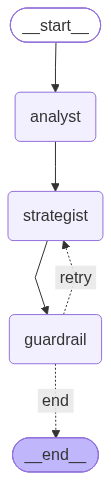

In [10]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(PipelineState)
graph.add_node("analyst", analyst_node)
graph.add_node("strategist", strategist_node)
graph.add_node("guardrail", guardrail_node)

graph.add_edge(START, "analyst")
graph.add_edge("analyst", "strategist")
graph.add_edge("strategist", "guardrail")
graph.add_conditional_edges(
    "guardrail",
    route_after_guardrail,
    {"retry": "strategist", "end": END},  # the loop-back edge
)

app = graph.compile()

INITIAL_STATE = {
    "signals": SIGNALS,
    "themes": "",
    "recommendation": "",
    "attempts": 0,
    "guardrail_passed": False,
    "guardrail_feedback": "",
}

# Draw the graph (PNG via mermaid.ink; falls back to Mermaid text if offline)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

In [11]:
# If you see a Workspace ID error, please add 'ANTHROPIC_WORKSPACE_ID' to your Colab Secrets (Left Sidebar -> Secrets 🔑)
# or environment variables, then run the notebook again.
try:
    result = app.invoke(INITIAL_STATE)
    print("THEMES:\n", result["themes"])
    print("\nRECOMMENDATION:\n", result["recommendation"])
    print(f"\nGuardrail passed: {result['guardrail_passed']}  |  Strategist attempts: {result['attempts']}")
except Exception as e:
    print(f"Error executing pipeline: {e}")
    print("\n👉 FIX: Go to your Anthropic Console, copy your Workspace ID, add it to your Colab Secrets as 'ANTHROPIC_WORKSPACE_ID', and rerun the setup cells.")

[guardrail] attempt 1: PASS
THEMES:
 # Key Themes

- **Onboarding experience is causing user drop-off and friction**
  - User interview (Maria, SMB owner): "I got lost during setup and gave up before finishing"
  - Support ticket #4903: "Wish there was a quick tour when I first logged in"

- **Navigation and discoverability issues are leading to support burden**
  - Support ticket #4821: "Can't find where to invite my team members. Confusing menu"
  - User interview (Maria, SMB owner): "I got lost during setup and gave up before finishing"

- **Competitors are investing in guided setup experiences**
  - Competitor teardown (RivalApp): just shipped a guided setup checklist with a progress bar

RECOMMENDATION:
 **Recommendation:** Build a guided onboarding checklist with progress tracking

**Rationale:** Directly addresses user drop-off during setup while reducing support burden from navigation confusion, and matches competitive table stakes.

Guardrail passed: True  |  Strategist attemp

### Prove the loop works (offline, no API cost)

Claude usually follows the "don't invent signals" instruction, so the live run above may pass on
the first attempt and never show the loop. To test the guardrail, swap in LangChain's
`FakeListChatModel`, which returns scripted responses in order, and force the Strategist to
hallucinate:

| Strategist attempt | Scripted recommendation | Expected guardrail result |
|---|---|---|
| 1 | Cites ticket **#5120**, which doesn't exist | Layer 1 (regex) fails → loop |
| 2 | Cites "our Q3 NPS survey", which doesn't exist | Layer 2 (LLM judge) fails → loop |
| 3 | Only uses real signals | Passes → END |

In [12]:
from langchain_core.language_models.fake_chat_models import FakeListChatModel

real_llm = llm
llm = FakeListChatModel(responses=[
    # analyst
    "- Setup drop-off (Maria interview, ticket #4821)\n- Users want a guided first run (ticket #4903, RivalApp teardown)",
    # strategist, attempt 1: invented ticket ID -> caught by the regex, no judge call
    "Build a guided setup checklist - ticket #5120 shows 40% of trials abandon setup.",
    # strategist, attempt 2: invented survey -> passes the regex, caught by the LLM judge
    "Build a guided setup checklist - our Q3 NPS survey ranked onboarding as the #1 complaint.",
    # LLM judge verdict on attempt 2
    '{"passed": false, "unsupported": ["Q3 NPS survey"]}',
    # strategist, attempt 3: grounded in the real signals
    "Build a guided setup checklist with a first-login tour - addresses setup drop-off (Maria, #4821) and the tour request (#4903).",
    # LLM judge verdict on attempt 3
    '{"passed": true, "unsupported": []}',
])

try:
    test = app.invoke(INITIAL_STATE)
finally:
    llm = real_llm  # always restore the real model

print("\nFINAL RECOMMENDATION:\n", test["recommendation"])
assert test["attempts"] == 3 and test["guardrail_passed"], "loop did not behave as expected"
print("\nLoop test passed: regex caught attempt 1, LLM judge caught attempt 2, attempt 3 accepted.")

[guardrail] attempt 1: FAIL -> Support ticket #5120 (not in SIGNALS)
[guardrail] attempt 2: FAIL -> Q3 NPS survey
[guardrail] attempt 3: PASS

FINAL RECOMMENDATION:
 Build a guided setup checklist with a first-login tour - addresses setup drop-off (Maria, #4821) and the tour request (#4903).

Loop test passed: regex caught attempt 1, LLM judge caught attempt 2, attempt 3 accepted.


## How LangGraph differs from CrewAI and Microsoft Agent Framework

| Framework | Core mental model | How multi-step flow is defined | Orchestration style |
|---|---|---|---|
| **LangGraph** | Explicit state graph | You wire nodes (functions/LLM calls) and edges yourself | Manual, graph-based — full control, more code |
| CrewAI | Role-based crew | You define `Agent`s (role/goal) and `Task`s; a `Process` (sequential/hierarchical) runs them | Opinionated, role-based — less code, less control |
| Microsoft Agent Framework | Unified successor to AutoGen + Semantic Kernel | Agents come from a chat client; you wire them with a Builder (Sequential, Concurrent, Handoff, GroupChat, Magentic) | Both — low-level like LangGraph, or pre-built patterns like CrewAI |


**Networking analogy:** LangGraph is like hand-building a network topology with static
routes. You declare every router (node) and every link (edge) yourself, and traffic
(state) only ever travels the path you cabled — including a deliberate loop back to an
earlier node if you want iterative refinement. Nothing moves that you didn't wire.

CrewAI trades that manual wiring for job descriptions and a process (see that notebook).
Microsoft Agent Framework gives you *both* — the same low-level node-and-edge control
(its `WorkflowBuilder`) plus pre-built patterns like the `SequentialBuilder` we used to
skip the manual graph entirely.

The `guardrail_node` uses LangGraph's **conditional edge**,
which is the "deliberate loop back" in the analogy. Note that CrewAI has no first-class way to
route a task back to an earlier task based on a check; you would need a custom Flow or a
manual retry. In LangGraph it's one `add_conditional_edges` call.
